# Forny 2023 — Multi-Omics Variant Re-ranking

## Background

This notebook re-ranks gene-level variant prioritizations from [Exomiser](https://exomiser.readthedocs.io)
by integrating multi-omics network evidence from **Napistu**.

The cohort (Forny 2023) consists of patients with methylmalonic acidemia (MMA) and related organic
acidemias, split into three clinical subgroups:
- **mut** (MMA001–MMA150): confirmed disease-causing variants
- **undiagnosed** (MMA151–MMA210): molecularly unresolved patients
- **unaffected** (MMA211–MMA230): healthy controls

## Analysis strategy

1. Load Exomiser gene-level variant rankings (phenotype + pathogenicity combined score)
2. Load Napistu multi-omics driver scores (proteomics + transcriptomics network enrichment)
3. Merge and compute a combined rank by averaging Exomiser rank and multi-omics attribute rank
4. Evaluate whether re-ranking improves retrieval of known causal genes
5. Inspect top candidates in undiagnosed patients

## Setup
Dependencies extend the `predict_driver_mutations` environment with `plotnine` for ggplot2-style plots.

In [1]:
# Environment: same as predict_driver_mutations with the addition:
# - plotnine: for plotting
!uv pip install plotnine

Audited 1 package in 25ms


In [2]:
import logging
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import plotnine as pn


logging.basicConfig(level=logging.INFO)

## Configuration

Paths and parameters are centralised in `inputs` and `params` to make the notebook
easy to adapt without touching analysis logic.

In [3]:
# votti env
#class inputs:  # type: ignore
#    _fol_input = Path("../../data/Forny2023/input")
#    # not published gene level exomiser prioritization
#    fn_exomiser_genes = _fol_input / "exomiser_genes_v1.csv"
#    # known variants based on the published variants in the supplementary
#    fn_known = _fol_input / '42255_2022_720_MOESM1_ESM_sup_tab1.csv'
#    # generated from predict_driver_mutations
#    fn_napistu = _fol_input / "../interim/mma_driver_mutation_rankings.parquet"

# sean env
class inputs:  # type: ignore
    _fol_input = Path("~/Desktop/DATA/Forny2023/input").expanduser()
    # not published gene level exomiser prioritization
    fn_exomiser_genes = _fol_input / "exomiser_genes_v1.csv"
    # known variants based on the published variants in the supplementary
    fn_known = _fol_input / '42255_2022_720_MOESM1_ESM_sup_tab1.csv'
    # generated from predict_driver_mutations
    fn_napistu = _fol_input / "../interim/mma_driver_mutation_rankings.parquet"


class params:  # type: ignore
    mma_group_dict = {
        'mut': (1, 150),
        'undiagnosed': (151, 210),
        'unaffected': (211, 230),
    }

    n_vertices_w_possible_scores = 19375



In [4]:
class V:
    # Common / Shared
    sample_id = 'sample_id'              # Unique identifier for each sample
    sample_subgroup = 'subgroup'         # Clinical subgroup (e.g., mut, undiagnosed)
    symbol = 'symbol'                    # Gene symbol
    
    # Known variants (dat_known)
    variant_hgnc_symbol = 'variant_hgnc_symbol' # Known disease-causing gene symbol
    variant_1_nt = 'variant_1_nt'        # Nucleotide variant information
    
    # Multi-omics drivers (dat_mma_driver)
    patient = 'patient'                  # Patient ID (matches sample_id)
    modality = 'modality'                # Multi-omics modality (e.g., genomics, proteomics)
    attribute_rank = 'attribute_rank'    # Rank of the gene in the multi-omics network
    log2_enrichment = 'log2_enrichment'  # Log2 enrichment score from multi-omics
    
    # Exomiser results (dat_exom)
    exomiser_gene_symbol = 'GENE_SYMBOL'          # Exomiser gene symbol
    exomiser_rank = 'RANK'                        # Exomiser variant rank
    exomiser_pipeline = 'pipeline'                # Variant calling pipeline used
    exomiser_id = 'ID'                            # Exomiser variant ID
    exomiser_p_value = 'P-VALUE'                  # Exomiser p-value
    exomiser_score = 'EXOMISER_GENE_COMBINED_SCORE' # Combined Exomiser score
    
    # Engineered / Computed features
    known_gene = 'known_gene'            # Mapped known disease gene for a sample
    known_symbol = 'known_symbol'        # Renamed known gene symbol for merging
    is_known = 'is_known'                # Boolean flag if gene matches known gene
    combined_rank = 'combined_rank'      # Average of exomiser rank and multi-omics rank
    re_rank = 're_rank'                  # Rank of the combined_rank within each sample/pipeline
    delta_rank = 'delta_rank'            # Difference between re_rank and original exomiser RANK
    attribute_rank_min = 'attribute_rank.min' # Minimum attribute rank across modalities
    log2_enrichment_max = 'log2_enrichment.max' # Maximum log2 enrichment across modalities
    log2_enrichment_prot = 'log2_enrichment.proteomics'
    log2_enrichment_trans = 'log2_enrichment.transcriptomics'
    is_retrieved = 'is_retrieved'        # Boolean if gene has multi-omics data

## Helper functions

`range_dict_to_id_mapping` converts the compact integer-range group definitions in `params`
to a flat `{sample_id: group}` lookup dict, which is used to annotate every dataframe with
the clinical subgroup.

`add_known` / `add_subgroup` are thin wrappers that keep the main pipeline readable.

In [5]:
# Helper functions
def range_dict_to_id_mapping(
    group_ranges: dict[str, tuple[int, int]],
    id_format="MMA{:03d}",
) -> dict[str, str]:
    """Converts a range dict to an id mapping

    Args:
        group_ranges (dict[str, tuple[int, int]]): A mapping from groups to ranges
            in the form {<groupname>: (startidx, stopidx)}
            with start_idx and stop_idx being the id range including start and stop
        id_format (str, optional): Format of the identifier. Defaults to "MMA%03d".

    Returns:
        dict[str, int]: dict mapping an id to a group

    Example:
        >>> range_dict_to_id_mapping({'group_a': (1, 2), 'group_b': (3, 3)})
        {'MMA001': 'group_a', 'MMA002': 'group_a', 'MMA003': 'group_b'}
    """
    return {
        **{
            id_format.format(i): g
            for g, sample_range in group_ranges.items()
            for i in np.arange(sample_range[0], sample_range[1] + 1)
        },
    }

def add_known(dat, kdict):
    return dat.assign(known_gene= lambda x:  x[V.sample_id].map(kdict))


def add_subgroup(x, group_dict: dict[str, str]):
    x=  x.assign(**{V.sample_subgroup: lambda x: x[V.sample_id].map(group_dict)})
    x[V.sample_subgroup] = x[V.sample_subgroup].astype(pd.CategoricalDtype(list(params.mma_group_dict.keys())))
    return x

## Data loading

Three datasets are loaded:
| Dataset | Source | Purpose |
|---|---|---|
| `dat_known` | Published supplementary table | Ground-truth causal variants |
| `dat_exom` | Unpublished Exomiser output | Variant prioritization per patient |
| `dat_mma_driver` | Napistu output | Multi-omics network driver scores |

In [6]:
dat_known = pd.read_csv(inputs.fn_known)
dat_known.head()

,sample_id,forny_pmid27167370_id,variant_hgnc_symbol,variant_1_nt,variant_1_aa,variant_2_nt,variant_2_aa,variant_comment
0,MMA001,2.0,MMUT,c.654A>C,p.Gln218His,c.1106G>A,p.Arg369His,NaN
1,MMA002,3.0,MMUT,c.1106G>A,p.Arg369His,c.1106G>A,p.Arg369His,NaN
2,MMA003,6.0,MMUT,c.409C>T,p.Ala137Val,c.655A>T,p.Asn219Tyr,NaN
3,MMA004,7.0,MMUT,c.607G>A,p.Gly203Arg,c.1106G>A,p.Arg369His,NaN
4,MMA005,8.0,MMUT,c.982C>T,p.Leu328Phe,c.982C>T,p.Leu328Phe,NaN


In [7]:
known_dict = dat_known.dropna(subset=V.variant_hgnc_symbol).set_index(V.sample_id)[V.variant_hgnc_symbol].to_dict()
samples_w_variants = dat_known.query(f'{V.variant_1_nt}.notna()')[V.sample_id]

In [8]:

group_dict = range_dict_to_id_mapping(params.mma_group_dict)
dat_exom = (pd.read_csv(inputs.fn_exomiser_genes)
            .pipe(add_subgroup, group_dict=group_dict)
)

Quick sanity check: how many patients per clinical subgroup are present in the Exomiser results?

In [9]:
(dat_exom
    .groupby([V.sample_subgroup])[V.sample_id].nunique()
)

/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_51839/4280603774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


subgroup
mut            150
undiagnosed     59
unaffected      20
Name: sample_id, dtype: int64

In [10]:
dat_exom[V.sample_subgroup]

0                mut
1                mut
2                mut
3                mut
4                mut
            ...     
56845    undiagnosed
56846    undiagnosed
56847    undiagnosed
56848    undiagnosed
56849    undiagnosed
Name: subgroup, Length: 56850, dtype: category
Categories (3, object): ['mut', 'undiagnosed', 'unaffected']

In [11]:
dat_mma_driver = pd.read_parquet(inputs.fn_napistu)

In [12]:
# Look at example
dat_mma_driver.query(f'{V.symbol} == "ACSF3"').sort_values(V.attribute_rank)

,patient,modality,symbol,log2_enrichment,attribute_rank
46171,MMA160,proteomics,ACSF3,2.589549,134.0
54774,MMA164,proteomics,ACSF3,2.381354,206.0
61143,MMA174,proteomics,ACSF3,2.236587,274.0
852952,MMA119,transcriptomics,ACSF3,0.125660,384.0
202177,MMA023,transcriptomics,ACSF3,0.502770,863.0
544046,MMA164,transcriptomics,ACSF3,0.211508,1081.0
224608,MMA192,transcriptomics,ACSF3,0.455765,1092.0
298417,MMA196,transcriptomics,ACSF3,0.356095,1160.0
947609,MMA041,transcriptomics,ACSF3,0.104552,1348.0
333454,MMA173,transcriptomics,ACSF3,0.324290,1398.0


In [13]:
known_genes = dat_known[V.variant_hgnc_symbol]

dat_exom = dat_exom.pipe(add_known, known_dict)

In [14]:
dat_mma_driver_filtered_known = dat_mma_driver.query(f'{V.symbol} in @known_genes').sort_values([V.patient, V.attribute_rank])

In [15]:
dat_mma_driver_filtered_known.query(f'{V.patient} == "MMA205"')

,patient,modality,symbol,log2_enrichment,attribute_rank
30716,MMA205,proteomics,MMAB,3.043009,103.0


In [16]:
dat_mma_driver[V.attribute_rank].max()

np.float64(5646.0)

In [17]:
(dat_mma_driver_filtered_known
    .assign(mma_nr   = lambda x: x[V.patient].str[3:].astype(int))
.query(f'mma_nr > 149 & {V.attribute_rank} < 300')
)

,patient,modality,symbol,log2_enrichment,attribute_rank,mma_nr
78971,MMA150,transcriptomics,MMUT,1.849845,295.0,150
66913,MMA153,proteomics,SUCLA2,2.111148,118.0,153
74574,MMA157,proteomics,MMUT,1.949697,190.0,157
28939,MMA159,proteomics,MMAB,3.106560,81.0,159
61309,MMA159,transcriptomics,SUCLA2,2.233013,225.0,159
27689,MMA160,transcriptomics,MMAB,3.150729,113.0,160
46171,MMA160,proteomics,ACSF3,2.589549,134.0,160
66452,MMA161,transcriptomics,SUCLA2,2.120745,245.0,161
7546,MMA164,transcriptomics,SUCLA2,4.289505,4.0,164
54774,MMA164,proteomics,ACSF3,2.381354,206.0,164


In [18]:
# Info log
logging.info(f'Number of MMA patients with variants in dat_exom: %d', dat_exom[V.sample_id].nunique())
logging.info(f'Number of MMA patients with variants in dat_mma_driver: %d', dat_mma_driver[V.patient].nunique())

INFO:root:Number of MMA patients with variants in dat_exom: 229
INFO:root:Number of MMA patients with variants in dat_mma_driver: 210


## Multi-omics context for known causal genes

Here we look at how the known causal genes rank in the Napistu multi-omics network
across all patients — regardless of Exomiser evidence. This helps assess how broadly
the network "sees" known MMA-related genes and whether the signal is modality-specific.
note: as the multi-omics network data is only for the main network module, it is sparse and does not contain all genes!

In [19]:
known_genes = dat_known[V.variant_hgnc_symbol].unique()

In [20]:
dat_mma_driver

,patient,modality,symbol,log2_enrichment,attribute_rank
6025,MMA001,proteomics,HSPB7,4.455639,1.0
6396,MMA001,proteomics,TBC1D20,4.413209,2.0
6407,MMA001,proteomics,CALHM5,4.412240,3.0
6425,MMA001,proteomics,FARP1,4.410710,4.0
6695,MMA001,proteomics,TMEM119,4.378890,5.0
...,...,...,...,...,...
967062,MMA210,transcriptomics,IVL,0.100203,3348.0
967122,MMA210,transcriptomics,NLRP3,0.100188,3349.0
967170,MMA210,transcriptomics,CD38,0.100177,3350.0
967184,MMA210,transcriptomics,ATP1B4,0.100175,3351.0


In [21]:
pdat =(dat_mma_driver.merge(dat_known
                     .rename(columns={V.variant_hgnc_symbol: V.known_symbol}),
                     left_on=[V.patient],
                     right_on=[V.sample_id], how='outer')
    .dropna(subset=V.known_symbol)
    .query(f'{V.symbol} in @known_genes')
     .eval(f'{V.is_known} = {V.symbol} == {V.known_symbol}')
      )

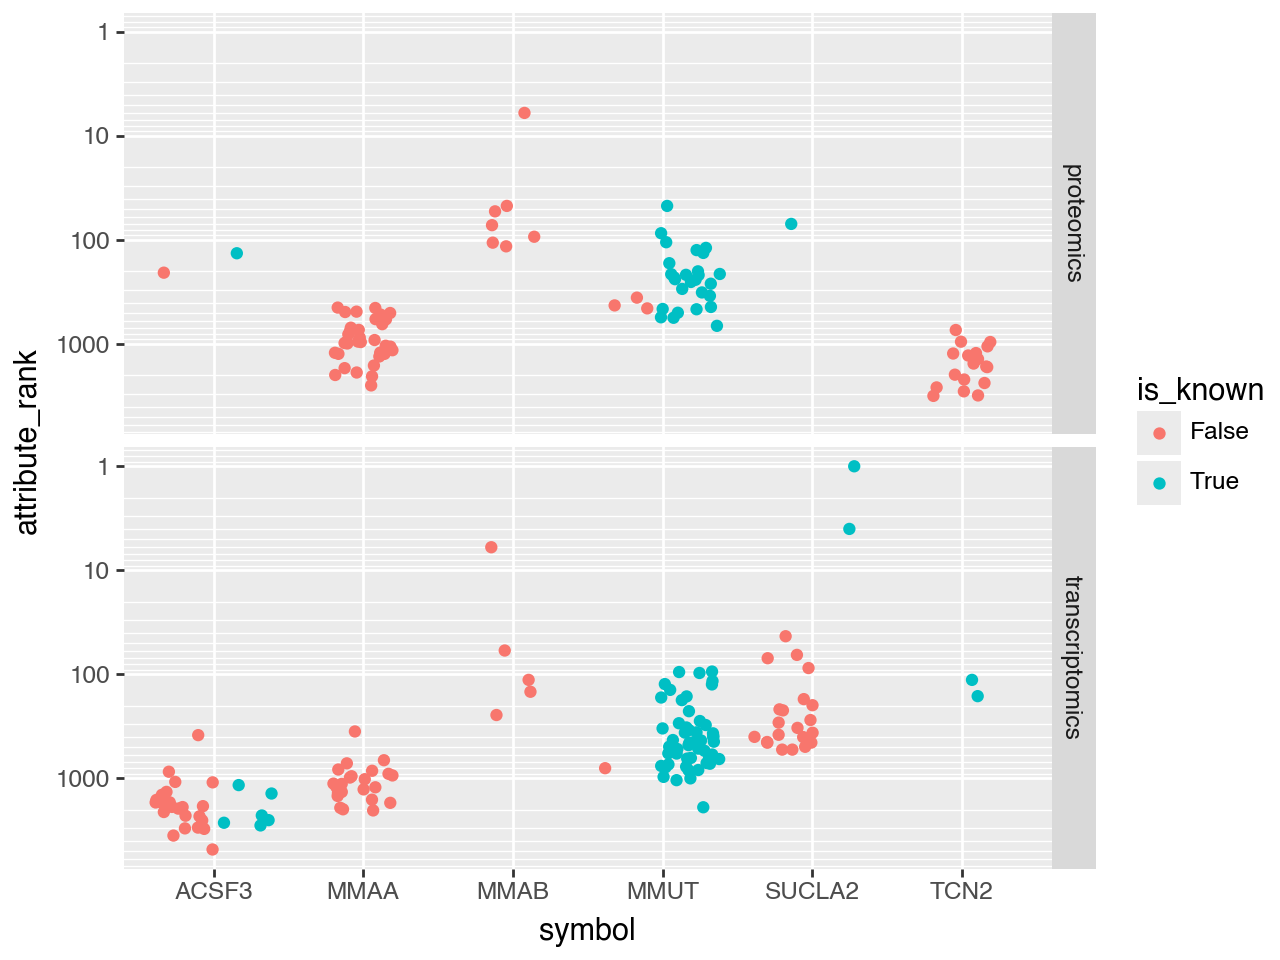

In [22]:
(pdat >>
 pn.ggplot(pn.aes(x=V.symbol, y=V.attribute_rank, color=V.is_known))
      + pn.facet_grid(f'{V.modality}~.')
     + pn.geom_point(position=pn.position_jitterdodge())
     +pn.scale_y_log10()
     +pn.coord_trans(y="reverse")
)

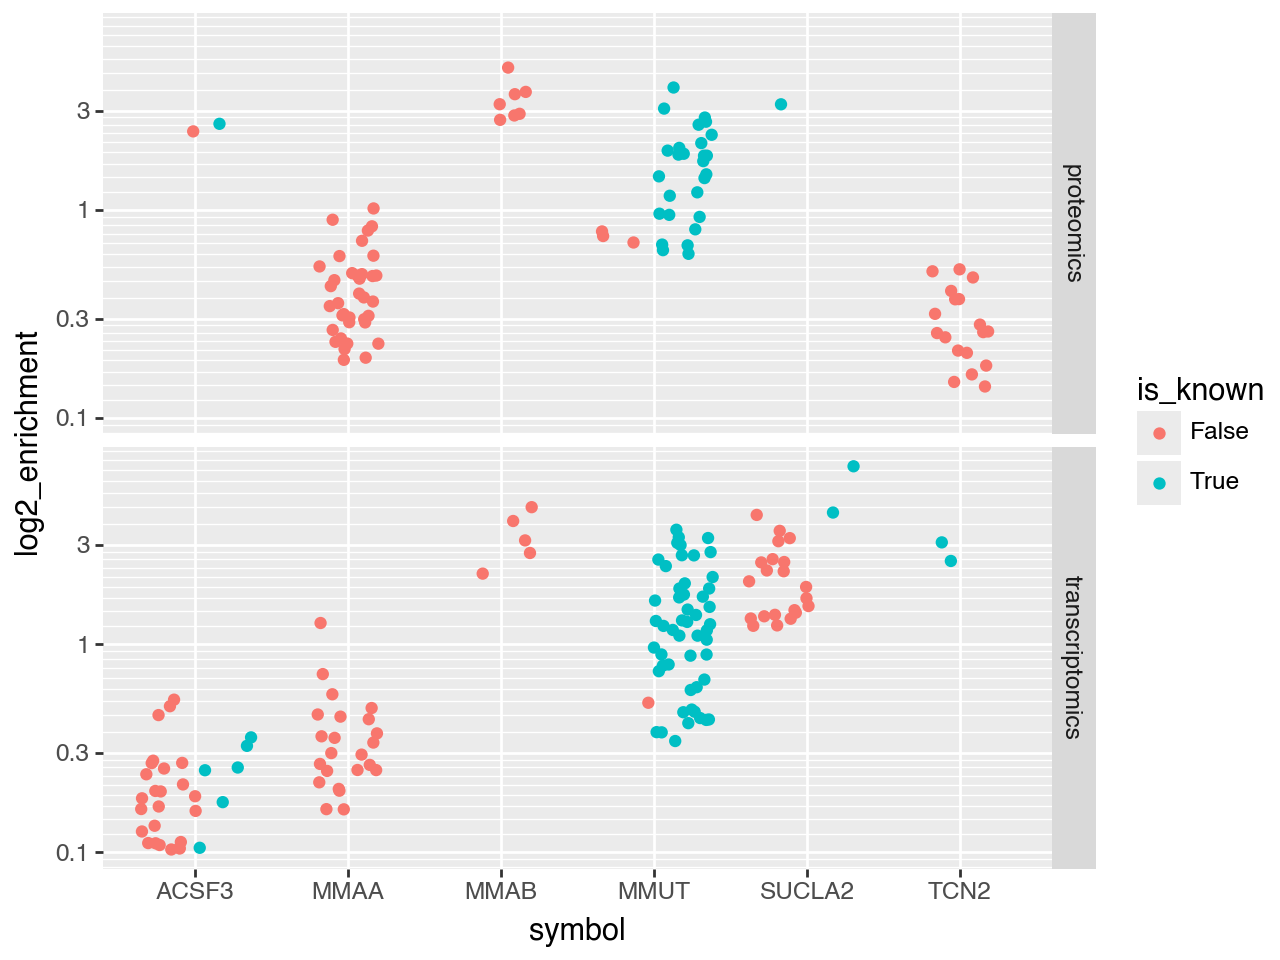

In [23]:
(pdat >>
 pn.ggplot(pn.aes(x=V.symbol, y=V.log2_enrichment, color=V.is_known))
      + pn.facet_grid(f'{V.modality}~.')
     + pn.geom_point(position=pn.position_jitterdodge())
     +pn.scale_y_log10()
)

### Per-patient, per-modality enrichment matrix

Wide-format view of `log2_enrichment` for all known causal genes across patients and modalities.
used to get an idea of the sparsity

In [24]:
dat_mma_driver.pivot_table(index=[V.patient, V.modality],
                           columns=V.symbol,
                           values=V.log2_enrichment)

symbol                       A1BG  A1CF       A2M     A2ML1   A3GALT2  \
patient modality                                                        
MMA001  proteomics            NaN   NaN  0.277812  0.139405       NaN   
        transcriptomics       NaN   NaN       NaN  0.110519       NaN   
MMA002  proteomics       0.124139   NaN  0.147483  0.182333       NaN   
        transcriptomics       NaN   NaN       NaN  0.153476       NaN   
MMA003  proteomics            NaN   NaN       NaN       NaN       NaN   
...                           ...   ...       ...       ...       ...   
MMA208  transcriptomics       NaN   NaN       NaN       NaN  0.215155   
MMA209  proteomics            NaN   NaN  0.144342       NaN       NaN   
        transcriptomics       NaN   NaN       NaN       NaN       NaN   
MMA210  proteomics            NaN   NaN       NaN       NaN       NaN   
        transcriptomics       NaN   NaN       NaN       NaN  0.242762   

symbol                     A4GALT     A4GNT      AAAS  AACS  AADAC  ...  \
patient modality                                                    ...   
MMA001  proteomics            NaN       NaN       NaN   NaN    NaN  ...   
        transcriptomics       NaN       NaN       NaN   NaN    NaN  ...   
MMA002  proteomics            NaN       NaN       NaN   NaN    NaN  ...   
        transcriptomics       NaN  0.146425       NaN   NaN    NaN  ...   
MMA003  proteomics            NaN       NaN       NaN   NaN    NaN  ...   
...                           ...       ...       ...   ...    ...  ...   
MMA208  transcriptomics       NaN  0.156939       NaN   NaN    NaN  ...   
MMA209  proteomics       0.183816  0.298824       NaN   NaN    NaN  ...   
        transcriptomics       NaN       NaN       NaN   NaN    NaN  ...   
MMA210  proteomics            NaN       NaN  0.170651   NaN    NaN  ...   
        transcriptomics       NaN       NaN       NaN   NaN    NaN  ...   

symbol                   ZWILCH  ZWINT      ZXDA      ZXDB  ZXDC    ZYG11A  \
patient modality                                                             
MMA001  proteomics          NaN    NaN       NaN       NaN   NaN       NaN   
        transcriptomics     NaN    NaN       NaN       NaN   NaN       NaN   
MMA002  proteomics          NaN    NaN       NaN       NaN   NaN       NaN   
        transcriptomics     NaN    NaN       NaN       NaN   NaN       NaN   
MMA003  proteomics          NaN    NaN       NaN       NaN   NaN       NaN   
...                         ...    ...       ...       ...   ...       ...   
MMA208  transcriptomics     NaN    NaN       NaN       NaN   NaN       NaN   
MMA209  proteomics          NaN    NaN       NaN       NaN   NaN       NaN   
        transcriptomics     NaN    NaN       NaN       NaN   NaN       NaN   
MMA210  proteomics          NaN    NaN  0.190101  0.190101   NaN       NaN   
        transcriptomics     NaN    NaN       NaN       NaN   NaN  0.237241   

symbol                     ZYG11B  ZYX  ZZEF1      ZZZ3  
patient modality                                         
MMA001  proteomics            NaN  NaN    NaN       NaN  
        transcriptomics       NaN  NaN    NaN       NaN  
MMA002  proteomics            NaN  NaN    NaN       NaN  
        transcriptomics       NaN  NaN    NaN       NaN  
MMA003  proteomics       0.268479  NaN    NaN  0.528264  
...                           ...  ...    ...       ...  
MMA208  transcriptomics       NaN  NaN    NaN       NaN  
MMA209  proteomics            NaN  NaN    NaN       NaN  
        transcriptomics       NaN  NaN    NaN       NaN  
MMA210  proteomics       0.287897  NaN    NaN  0.103344  
        transcriptomics       NaN  NaN    NaN       NaN  

[412 rows x 19309 columns]

## Multi-omics driver summarization

Napistu outputs one row per *(patient, gene, modality)* triplet.
`summarize_drivers` collapses this to *(patient, gene)* by:
- taking the **maximum** `log2_enrichment` across modalities (best network evidence)
- taking the **minimum** `attribute_rank` across modalities (best network rank)

Individual modality columns (proteomics, transcriptomics) are retained for later inspection.

In [25]:

def summarize_drivers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize driver mutation rankings by pivoting across modalities.
    
    Computes the maximum log2 enrichment and minimum attribute rank
    across all available modalities for each patient and gene symbol.
    
    Args:
        df: DataFrame containing 'patient', 'symbol', 'modality',
            'log2_enrichment', and 'attribute_rank'.
            
    Returns:
        pd.DataFrame: Pivoted summary with flattened column names.
    """
    df_sum = df.pivot_table(
        index=[V.patient, V.symbol],
        columns=[V.modality],
        values=[V.log2_enrichment, V.attribute_rank]
    )

    df_sum[(V.log2_enrichment, 'max')] = df_sum[V.log2_enrichment].max(axis=1)
    df_sum[(V.attribute_rank, 'min')] = df_sum[V.attribute_rank].min(axis=1)
    
    df_sum.columns = [f"{c[0]}.{c[1]}" for c in df_sum.columns]
    
    return df_sum.reset_index()

dat_mma_driver_sum = summarize_drivers(dat_mma_driver)
dat_mma_driver_sum

,patient,symbol,attribute_rank.proteomics,attribute_rank.transcriptomics,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min
0,MMA001,A2M,1411.0,NaN,0.277812,NaN,0.277812,1411.0
1,MMA001,A2ML1,3365.0,2530.0,0.139405,0.110519,0.139405,2530.0
2,MMA001,AADACL3,2356.0,NaN,0.194242,NaN,0.194242,2356.0
3,MMA001,AARD,1234.0,1099.0,0.307802,0.249503,0.307802,1099.0
4,MMA001,ABCA1,3889.0,NaN,0.116050,NaN,0.116050,3889.0
...,...,...,...,...,...,...,...,...
888722,MMA210,ZXDA,1776.0,NaN,0.190101,NaN,0.190101,1776.0
888723,MMA210,ZXDB,1776.0,NaN,0.190101,NaN,0.190101,1776.0
888724,MMA210,ZYG11A,NaN,1497.0,NaN,0.237241,0.237241,1497.0
888725,MMA210,ZYG11B,1095.0,NaN,0.287897,NaN,0.287897,1095.0


## Merging Exomiser and multi-omics evidence

Exomiser was run with 3 separate variant calling pipelines:
- **exomiser**: standard SNV/indel pipeline based on deepvariant calls
- **exomiser_svc**: addition of structural variants to the standard pipeline
- **genomiser**: includes intronic/upstream/downstream and CNV variant calls

We keep all pipelines and stratify all downstream comparisons by pipeline.
Genes without Napistu coverage receive a high penalty rank (`fill_rank=6000`).

In [26]:
dat_exom[V.exomiser_pipeline].unique()

array(['exomiser', 'exomiser_svc_tiddit', 'exomiser_svc_manta',
       'exomiser_svc_delly', 'genomiser'], dtype=object)

In [27]:
dat_genom = dat_exom.query(f'{V.exomiser_pipeline} == "exomiser"')

In [28]:
(dat_exom
    .sort_values([V.exomiser_rank],
                ascending=True)
    .query(f'{V.exomiser_pipeline} == "exomiser"')
     .query(f'{V.sample_id} == "MMA023"')
)

,sample_id,pipeline,RANK,ID,GENE_SYMBOL,ENTREZ_GENE_ID,MOI,P-VALUE,EXOMISER_GENE_COMBINED_SCORE,EXOMISER_GENE_PHENO_SCORE,...,OMIM_SCORE,MATCHES_CANDIDATE_GENE,HUMAN_PHENO_EVIDENCE,MOUSE_PHENO_EVIDENCE,FISH_PHENO_EVIDENCE,HUMAN_PPI_EVIDENCE,MOUSE_PPI_EVIDENCE,FISH_PPI_EVIDENCE,subgroup,known_gene
7250,MMA023,exomiser,1,MPO_AD,MPO,4353,AD,0.0085,0.2788,0.3034,...,1.0,0,"Alzheimer disease, susceptibility to (OMIM:104...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
7251,MMA023,exomiser,2,HLA-DRB1_AD,HLA-DRB1,3123,AD,0.0113,0.2149,0.4469,...,1.0,0,"Sarcoidosis, susceptibility to, 1 (OMIM:181000...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
7252,MMA023,exomiser,3,EPB41_AD,EPB41,2035,AD,0.0155,0.1531,0.4080,...,1.0,0,Hereditary elliptocytosis (ORPHA:288): Methylm...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7253,MMA023,exomiser,4,RTL1_AD,RTL1,388015,AD,0.0157,0.1513,0.2860,...,1.0,0,Temple syndrome due to paternal 14q32.2 hypome...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7254,MMA023,exomiser,5,OCA2_AD,OCA2,4948,AD,0.0177,0.1344,0.2156,...,1.0,0,Prader-Willi syndrome due to paternal deletion...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7255,MMA023,exomiser,6,MSH4_AD,MSH4,4438,AD,0.0188,0.1254,0.2172,...,1.0,0,Spermatogenic failure 2 (OMIM:108420): Methylm...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7256,MMA023,exomiser,7,COL6A3_AD,COL6A3,1293,AD,0.0207,0.1127,0.2680,...,1.0,0,Bethlem muscular dystrophy (ORPHA:610): Methyl...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7257,MMA023,exomiser,8,POGLUT1_AD,POGLUT1,56983,AD,0.0231,0.0997,0.1832,...,1.0,0,"Muscular dystrophy, limb-girdle, autosomal rec...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
7258,MMA023,exomiser,9,KMT2C_AD,KMT2C,58508,AD,0.0245,0.0922,0.2410,...,1.0,0,Kleefstra syndrome due to a point mutation (OR...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
7259,MMA023,exomiser,10,COL6A3_AR,COL6A3,1293,AR,0.0272,0.0794,0.2680,...,1.0,0,Bethlem muscular dystrophy (ORPHA:610): Methyl...,NaN,NaN,NaN,NaN,NaN,mut,MMUT


In [29]:
def merge_variants(
    df_exom: pd.DataFrame, 
    df_driver_sum: pd.DataFrame
) -> pd.DataFrame:
    """
    Merges exomiser variant rankings with multi-omics driver summaries.
    
    Args:
        df_exom: Exomiser variant dataframe.
        df_driver_sum: Multi-omics driver summary dataframe.
        
    Returns:
        pd.DataFrame: Merged dataframe containing both exomiser and multi-omics data.
    """
    return (
        df_exom
        # remove duplicates on the gene level
        # usually this is because AR and AD are listed twice
        .sort_values([V.exomiser_rank], ascending=True)
        .drop_duplicates(subset=[V.sample_id, V.exomiser_pipeline, V.exomiser_gene_symbol])
        # Outer merge to keep all exomiser variants
        .merge(
            df_driver_sum, 
            left_on=[V.sample_id, V.exomiser_gene_symbol],
            right_on=[V.patient, V.symbol],
            how='left'
        )
        # make sure symbol is the not NaN
        .assign(**{V.symbol: lambda x: x[V.exomiser_gene_symbol]})
    )

def rerank_variants(
    df_merged: pd.DataFrame, 
    fill_rank: int = 6000
) -> pd.DataFrame:
    """
    Calculates an updated combined rank based on exomiser and multi-omics ranks.
    
    Args:
        df_merged: Merged dataframe containing 'RANK' and 'attribute_rank.min'.
        fill_rank: Rank to fill for genes without multi-omics data.
        
    Returns:
        pd.DataFrame: Dataframe with new rank metrics ('combined_rank',
            're_rank', and 'delta_rank').
    """
    df_reranked = df_merged.copy()
    
    df_reranked[V.combined_rank] = df_reranked[[V.exomiser_rank, V.attribute_rank_min]].fillna(fill_rank).mean(axis=1)
    
    df_reranked[V.re_rank] = (
        df_reranked.groupby([V.sample_id, V.exomiser_pipeline])[V.combined_rank]
        .rank(method='min')
    )
    
    df_reranked[V.delta_rank] = df_reranked[V.re_rank] - df_reranked[V.exomiser_rank]
    
    return df_reranked

dat_merged = merge_variants(dat_exom, dat_mma_driver_sum)
dat_merged = rerank_variants(dat_merged)

## Benchmarking: recovery of causal gene within patient-level PPR enrichments

As a first simple test we can assess whether patient's PPR subgraphs are enriched for their known causal gene (when known).

### Test framing

Each patient is an independent trial with a patient-specific success probability under the null:

$$p_i = K_i / N_i$$

where $K_i$ is the size of patient $i$'s enriched list and $N_i$ is the number of genes that could possibly appear in it (genes quantified for that patient). The outcome $X_i \in \{0, 1\}$ is whether the causal gene is in the enriched list.

Under the null (causal gene is a random draw from the $N_i$ measurable genes), $X_i \sim \text{Bernoulli}(p_i)$.

### The test: Poisson binomial

The sum $S = \sum_i X_i$ follows a **Poisson binomial** distribution (sum of independent Bernoullis with *different* success probabilities). This is the correct null — it's what Fisher's exact fails to capture because the $p_i$ vary across patients.

**Test:**

- Observed: $S_\text{obs} = \sum_i X_i$ (number of patients whose causal gene was in their enriched list)
- Expected under null: $\mathbb{E}[S] = \sum_i p_i$
- One-sided p-value: $P(S \geq S_\text{obs})$ under Poisson binomial with parameters $\{p_i\}$

In [30]:
dat_hits = dat_merged.query(f'{V.exomiser_gene_symbol} == {V.known_gene} | {V.known_gene}.isna()')

dat_hits

,sample_id,pipeline,RANK,ID,GENE_SYMBOL,ENTREZ_GENE_ID,MOI,P-VALUE,EXOMISER_GENE_COMBINED_SCORE,EXOMISER_GENE_PHENO_SCORE,...,symbol,attribute_rank.proteomics,attribute_rank.transcriptomics,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,combined_rank,re_rank,delta_rank
0,MMA053,exomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9680,0.7250,...,MMUT,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,14.0,13.0
3,MMA112,exomiser_svc_tiddit,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,MMUT,NaN,403.0,NaN,1.465657,1.465657,403.0,202.0,2.0,1.0
5,MMA156,exomiser_svc_manta,1,ACSF3_AR,ACSF3,197322,AR,0.0000,0.9933,0.8891,...,ACSF3,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,5.0,4.0
7,MMA171,genomiser,1,SLC25A1_AR,SLC25A1,6576,AR,0.0001,0.9729,0.8247,...,SLC25A1,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,7.0,6.0
8,MMA211,exomiser_svc_manta,1,CPOX_AD,CPOX,1371,AD,0.0001,0.9815,0.7767,...,CPOX,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54824,MMA177,exomiser_svc_tiddit,50,CPT1A_AR,CPT1A,1374,AR,0.0097,0.2385,0.6366,...,CPT1A,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,48.0,-2.0
54826,MMA215,exomiser_svc_manta,50,KLHL3_AD,KLHL3,26249,AD,0.0058,0.3748,0.3456,...,KLHL3,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,48.0,-2.0
54830,MMA230,genomiser,50,UROC1_AR,UROC1,131669,AR,0.0136,0.1778,0.6904,...,UROC1,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,50.0,0.0
54831,MMA227,exomiser_svc_tiddit,50,NOD2_AD,NOD2,64127,AD,0.0069,0.3185,0.3217,...,NOD2,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,48.0,-2.0


In [31]:
regulon_versions = {
    "transcriptomics": dat_mma_driver_sum.dropna(subset=[V.log2_enrichment_trans]),
    "proteomics": dat_mma_driver_sum.dropna(subset=[V.log2_enrichment_prot]),
    "transcriptomics or proteomics": dat_mma_driver_sum,
}

# one known causal gene per patient
patient_known = (
    dat_exom[[V.sample_id, V.known_gene]]
    .dropna()
    .drop_duplicates()
    .rename(columns={V.sample_id: V.patient})
)

results = []
for regulon_name, dat_regulon in regulon_versions.items():
    # regulon size K_i per patient
    regulon_size = (
        dat_regulon.groupby(V.patient)[V.symbol]
        .nunique()
        .rename("K")
        .reset_index()
    )

    # membership: does patient i's regulon contain their known gene?
    membership = (
        dat_regulon[[V.patient, V.symbol]]
        .merge(patient_known, on=V.patient, how="inner")
        .assign(hit=lambda d: d[V.symbol] == d[V.known_gene])
        .groupby(V.patient)["hit"]
        .any()
        .rename("X")
        .reset_index()
    )

    summary = (
        patient_known
        .merge(regulon_size, on=V.patient, how="left")
        .merge(membership, on=V.patient, how="left")
        .assign(regulon=regulon_name)
    )
    # patients with no regulon get K=0, X=False
    summary["K"] = summary["K"].fillna(0).astype(int)
    summary["X"] = summary["X"].fillna(False)

    results.append(summary)

dat_regulon_membership = pd.concat(results, ignore_index=True)


/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_51839/3854084029.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [32]:
from scipy.stats import poisson_binom

N = params.n_vertices_w_possible_scores

def poisson_binomial_test(df):
    p = df["K"].to_numpy() / N
    s_obs = int(df["X"].sum())
    k = len(df)
    expected = p.sum()
    pb = poisson_binom(p)
    p_value = pb.sf(s_obs - 1)  # P(S >= s_obs)
    return pd.Series({
        "n_patients": k,
        "S_obs": s_obs,
        "E[S]": expected,
        "ratio": s_obs / expected if expected > 0 else np.nan,
        "p_value": p_value,
    })

dat_regulon_test = (
    dat_regulon_membership
    .groupby("regulon", sort=False)
    .apply(poisson_binomial_test)
    .reset_index()
)
dat_regulon_test

/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_51839/39060750.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,regulon,n_patients,S_obs,E[S],ratio,p_value
0,transcriptomics,177.0,61.0,19.113445,3.191471,4.440892e-16
1,proteomics,177.0,29.0,23.199123,1.250047,1.193543e-01
2,transcriptomics or proteomics,177.0,79.0,38.875923,2.032106,1.206402e-11


In [33]:
# per-mutation x regulon
dat_regulon_test_by_gene = (
    dat_regulon_membership
    .groupby(["known_gene", "regulon"], sort=False)
    .apply(poisson_binomial_test, include_groups=False)
    .reset_index()
)

dat_regulon_test_by_gene

,known_gene,regulon,n_patients,S_obs,E[S],ratio,p_value
0,MMUT,transcriptomics,148.0,51.0,15.996129,3.188271,8.659740e-15
1,SUCLA2,transcriptomics,3.0,2.0,0.281342,7.108787,2.364097e-02
2,ACSF3,transcriptomics,20.0,6.0,2.202839,2.723758,1.720800e-02
3,MMAA,transcriptomics,2.0,0.0,0.123768,0.000000,1.000000e+00
4,TCN2,transcriptomics,3.0,2.0,0.373316,5.357390,4.250592e-02
5,MMAB,transcriptomics,1.0,0.0,0.136052,0.000000,1.000000e+00
6,MMUT,proteomics,148.0,27.0,19.723200,1.368946,5.409917e-02
7,SUCLA2,proteomics,3.0,1.0,0.338426,2.954857,3.019395e-01
8,ACSF3,proteomics,20.0,1.0,2.409290,0.415060,9.244622e-01
9,MMAA,proteomics,2.0,0.0,0.242168,0.000000,1.000000e+00


## Benchmarking: rank of causal gene within patient-level PPR enrichments

Conditional on the causal gene being recovered in a patient's enriched list, we can ask whether it ranks *high* within that list — i.e., whether the enrichment score for the known causal gene is among the top hits rather than a marginal member of the regulon.

### Test framing

For each patient $i$ whose causal gene is in their enriched list, let $r_i$ be the rank of the causal gene within that list (rank 1 = highest enrichment) and $K_i$ be the size of the list. Define the normalized rank:

$$u_i = (r_i - 0.5) / K_i \in (0, 1)$$

The $-0.5$ is a continuity correction that centers each rank within its bin.

Under the null (causal gene is a uniform random draw from the $K_i$ list members), $u_i \sim \text{Uniform}(0, 1)$. Under the alternative (causal gene ranks high), the distribution of $u_i$ is skewed toward 0.

### The test: Stouffer's Z

Apply the **probit transform** to convert each normalized rank into a z-score:

$$z_i = \Phi^{-1}(1 - u_i)$$

where $\Phi$ is the standard normal CDF and $\Phi^{-1}$ is its inverse (the quantile / probit function). By the probability integral transform, if $u_i \sim \text{Uniform}(0, 1)$ then $z_i \sim \mathcal{N}(0, 1)$ exactly. Using $1 - u_i$ rather than $u_i$ is a sign convention so that small $u_i$ (causal gene ranks high) maps to large positive $z_i$.

Combine across patients with Stouffer's method:

$$Z = \frac{1}{\sqrt{k}} \sum_{i=1}^{k} z_i$$

where $k$ is the number of patients whose causal gene was recovered. Under the null, $Z \sim \mathcal{N}(0, 1)$.

**Test:**

- Observed: $Z_\text{obs} = \frac{1}{\sqrt{k}} \sum_i \Phi^{-1}(1 - u_i)$
- Null distribution: $Z \sim \mathcal{N}(0, 1)$
- One-sided p-value: $P(Z \geq Z_\text{obs}) = 1 - \Phi(Z_\text{obs})$

This formulation naturally handles heterogeneous list sizes $K_i$ across patients, since the normalization puts all ranks on a common $(0, 1)$ scale before combining.

In [34]:
regulon_version_ranking_attrs = {
    "transcriptomics": "attribute_rank.transcriptomics",
    "proteomics": "attribute_rank.proteomics",
    "transcriptomics or proteomics": "attribute_rank.min",
}

driver_ranks = list()
for regulon_name, ranking_attr in regulon_version_ranking_attrs.items():
    
    driver_ranks.append(
        dat_regulon[[V.patient, V.symbol, ranking_attr]]
            .rename(columns={ranking_attr: "attribute_rank"})
            .dropna(subset=["attribute_rank"])
            .merge(patient_known, on=V.patient, how="inner")
            .assign(regulon=regulon_name)
            .sort_values([V.patient, V.attribute_rank])
            .assign(attribute_rank=lambda d: d.groupby(V.patient)["attribute_rank"]
                                          .rank(method="average", ascending=True))
    )

driver_ranks = pd.concat(driver_ranks)
driver_ranks.head()

,patient,symbol,attribute_rank,known_gene,regulon
822,MMA001,HDHD2,1.0,MMUT,transcriptomics
1823,MMA001,TMEM132A,2.0,MMUT,transcriptomics
1070,MMA001,LBH,3.0,MMUT,transcriptomics
114,MMA001,ARLN,4.0,MMUT,transcriptomics
1842,MMA001,TMEM44,5.0,MMUT,transcriptomics


In [35]:
from scipy.stats import norm

def stouffer_rank_test(df):
    u = (df["attribute_rank"].to_numpy() - 0.5) / df["K"].to_numpy()
    z = norm.isf(u)  # Phi^-1(1 - u)
    k = len(u)
    Z = z.sum() / np.sqrt(k)
    return pd.Series({
        "n_patients": k,
        "mean_u": u.mean(),
        "median_u": np.median(u),
        "Z": Z,
        "p_value": norm.sf(Z),
    })

# attach regulon size K_i per (patient, regulon)
driver_ranks_w_size = driver_ranks.assign(
    K=lambda d: d.groupby([V.patient, "regulon"])[V.symbol].transform("nunique"),
)

# keep only the causal gene's row per patient
hits = driver_ranks_w_size[driver_ranks_w_size[V.symbol] == driver_ranks_w_size[V.known_gene]].copy()

# per regulon
dat_rank_test = (
    hits.groupby("regulon", sort=False)
    .apply(stouffer_rank_test, include_groups=False)
    .reset_index()
)

dat_rank_test


,regulon,n_patients,mean_u,median_u,Z,p_value
0,transcriptomics,61.0,0.205308,0.155393,7.698709,6.872386e-15
1,proteomics,29.0,0.065149,0.066799,8.450684,1.448002e-17
2,transcriptomics or proteomics,79.0,0.152033,0.103215,10.678502,6.416286e-27


In [36]:
# per known_gene x regulon
dat_rank_test_by_gene = (
    hits
    .groupby([V.known_gene, "regulon"], sort=False)
    .apply(stouffer_rank_test, include_groups=False)
    .reset_index()
    [[V.known_gene, "regulon", "n_patients", "mean_u", "median_u", "Z", "p_value"]]
)

dat_rank_test_by_gene

,known_gene,regulon,n_patients,mean_u,median_u,Z,p_value
0,MMUT,transcriptomics,51.0,0.175620,0.149202,7.344924,1.029384e-13
1,ACSF3,transcriptomics,6.0,0.577064,0.500898,-0.854753,8.036561e-01
2,SUCLA2,transcriptomics,2.0,0.000968,0.000968,4.577536,2.352421e-06
3,TCN2,transcriptomics,2.0,0.051426,0.051426,2.330404,9.892396e-03
4,MMUT,proteomics,27.0,0.067763,0.067575,8.032777,4.764542e-16
5,ACSF3,proteomics,1.0,0.032592,0.032592,1.843995,3.259191e-02
6,SUCLA2,proteomics,1.0,0.027127,0.027127,1.924799,2.712724e-02
7,MMUT,transcriptomics or proteomics,68.0,0.128289,0.103651,10.120271,2.245860e-24
8,ACSF3,transcriptomics or proteomics,6.0,0.524051,0.534882,-0.003745,5.014942e-01
9,SUCLA2,transcriptomics or proteomics,3.0,0.012247,0.001871,4.743614,1.049692e-06


u summary:
                               count      mean       std       min       25%  \
regulon                                                                        
proteomics                      29.0  0.065149  0.033343  0.012313  0.045361   
transcriptomics                 61.0  0.205308  0.177164  0.000191  0.075000   
transcriptomics or proteomics   79.0  0.152033  0.156606  0.000232  0.060720   

                                    50%       75%       max  
regulon                                                      
proteomics                     0.066799  0.086679  0.158186  
transcriptomics                0.155393  0.295810  0.983499  
transcriptomics or proteomics  0.103215  0.178573  0.824888  


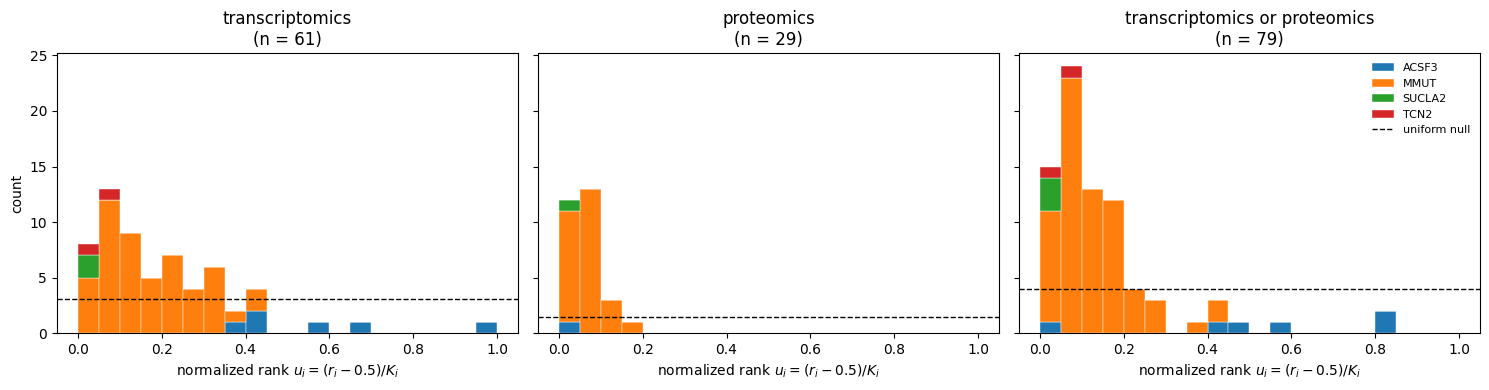

In [37]:
import matplotlib.pyplot as plt

hits = (
    driver_ranks[driver_ranks[V.symbol] == driver_ranks[V.known_gene]]
    .copy()
)

# K_i = regulon size per (patient, regulon), computed on the FULL driver_ranks
k_map = (
    driver_ranks.groupby([V.patient, "regulon"])[V.symbol]
    .nunique()
    .rename("K")
    .reset_index()
)
hits = hits.merge(k_map, on=[V.patient, "regulon"], how="left")
hits["u"] = (hits["attribute_rank"] - 0.5) / hits["K"]

print("u summary:")
print(hits.groupby("regulon")["u"].describe())

regulons = list(regulon_version_ranking_attrs.keys())
known_genes = sorted(hits[V.known_gene].unique())
bins = np.linspace(0, 1, 21)

fig, axes = plt.subplots(1, len(regulons), figsize=(5 * len(regulons), 4), sharey=True)

for ax, regulon in zip(axes, regulons):
    sub = hits[hits["regulon"] == regulon]
    stacks = [sub.loc[sub[V.known_gene] == g, "u"].to_numpy() for g in known_genes]
    ax.hist(stacks, bins=bins, stacked=True, label=known_genes,
            edgecolor="white", linewidth=0.3)
    ax.axhline(len(sub) / (len(bins) - 1), color="k", linestyle="--",
               linewidth=1, label="uniform null")
    ax.set_title(f"{regulon}\n(n = {len(sub)})")
    ax.set_xlabel("normalized rank $u_i = (r_i - 0.5) / K_i$")

axes[0].set_ylabel("count")
axes[-1].legend(loc="upper right", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## Benchmarking: known causal genes

`dat_hits` restricts to:
1. Rows where the Exomiser gene matches the known causal gene — measures retrieval quality.
2. Rows where no known gene exists (undiagnosed) — potential novel discoveries.

**Key metric:** `delta_rank = re_rank − exomiser_rank`  
Negative values mean the combined ranking **improves** on Exomiser alone.

In [38]:
dat_merged[[V.sample_id, V.exomiser_rank, V.combined_rank, V.attribute_rank_min]]

,sample_id,RANK,combined_rank,attribute_rank.min
0,MMA053,1,3000.5,NaN
1,MMA148,1,3000.5,NaN
2,MMA140,1,3000.5,NaN
3,MMA112,1,202.0,403.0
4,MMA042,1,3000.5,NaN
...,...,...,...,...
54828,MMA089,50,762.0,1474.0
54829,MMA134,50,3025.0,NaN
54830,MMA230,50,3025.0,NaN
54831,MMA227,50,3025.0,NaN


In [39]:
dat_merged.query(f'{V.exomiser_pipeline} == "exomiser"')[[V.sample_id, V.exomiser_id]]

,sample_id,ID
0,MMA053,MMUT_AR
70,MMA179,ACSF3_AR
72,MMA089,MMUT_AR
74,MMA152,HLA-DRB1_AD
75,MMA196,ACSF3_AR
...,...,...
54751,MMA168,ZNF749_AD
54779,MMA205,OTOF_AD
54785,MMA208,MYH4_AD
54807,MMA049,P2RY12_AD


In [40]:
dat_merged

,sample_id,pipeline,RANK,ID,GENE_SYMBOL,ENTREZ_GENE_ID,MOI,P-VALUE,EXOMISER_GENE_COMBINED_SCORE,EXOMISER_GENE_PHENO_SCORE,...,symbol,attribute_rank.proteomics,attribute_rank.transcriptomics,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,combined_rank,re_rank,delta_rank
0,MMA053,exomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9680,0.7250,...,MMUT,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,14.0,13.0
1,MMA148,exomiser_svc_delly,1,MLYCD_AR,MLYCD,23417,AR,0.0000,0.9880,0.8190,...,MLYCD,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,7.0,6.0
2,MMA140,genomiser,1,SLC25A1_AR,SLC25A1,6576,AR,0.0001,0.9729,0.8247,...,SLC25A1,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,8.0,7.0
3,MMA112,exomiser_svc_tiddit,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,MMUT,NaN,403.0,NaN,1.465657,1.465657,403.0,202.0,2.0,1.0
4,MMA042,genomiser,1,SLC25A1_AR,SLC25A1,6576,AR,0.0001,0.9729,0.8247,...,SLC25A1,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,9.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54828,MMA089,exomiser_svc_tiddit,50,CSF2RA_XD,CSF2RA,1438,XD,0.0108,0.2172,0.2715,...,CSF2RA,1474.0,NaN,0.227529,NaN,0.227529,1474.0,762.0,2.0,-48.0
54829,MMA134,exomiser_svc_manta,50,COX14_AR,COX14,84987,AR,0.0027,0.5926,0.4309,...,COX14,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,48.0,-2.0
54830,MMA230,genomiser,50,UROC1_AR,UROC1,131669,AR,0.0136,0.1778,0.6904,...,UROC1,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,50.0,0.0
54831,MMA227,exomiser_svc_tiddit,50,NOD2_AD,NOD2,64127,AD,0.0069,0.3185,0.3217,...,NOD2,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,48.0,-2.0


In [41]:
dat_hits = dat_merged.query(f'{V.exomiser_gene_symbol} == {V.known_gene} | {V.known_gene}.isna()')

    

In [42]:
dat_hits[V.symbol]

0           MMUT
3           MMUT
5          ACSF3
7        SLC25A1
8           CPOX
          ...   
54824      CPT1A
54826      KLHL3
54830      UROC1
54831       NOD2
54832      PREPL
Name: symbol, Length: 13329, dtype: object

/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/applications/forny_2023/.venv/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 29'. Pick better value with 'binwidth'.


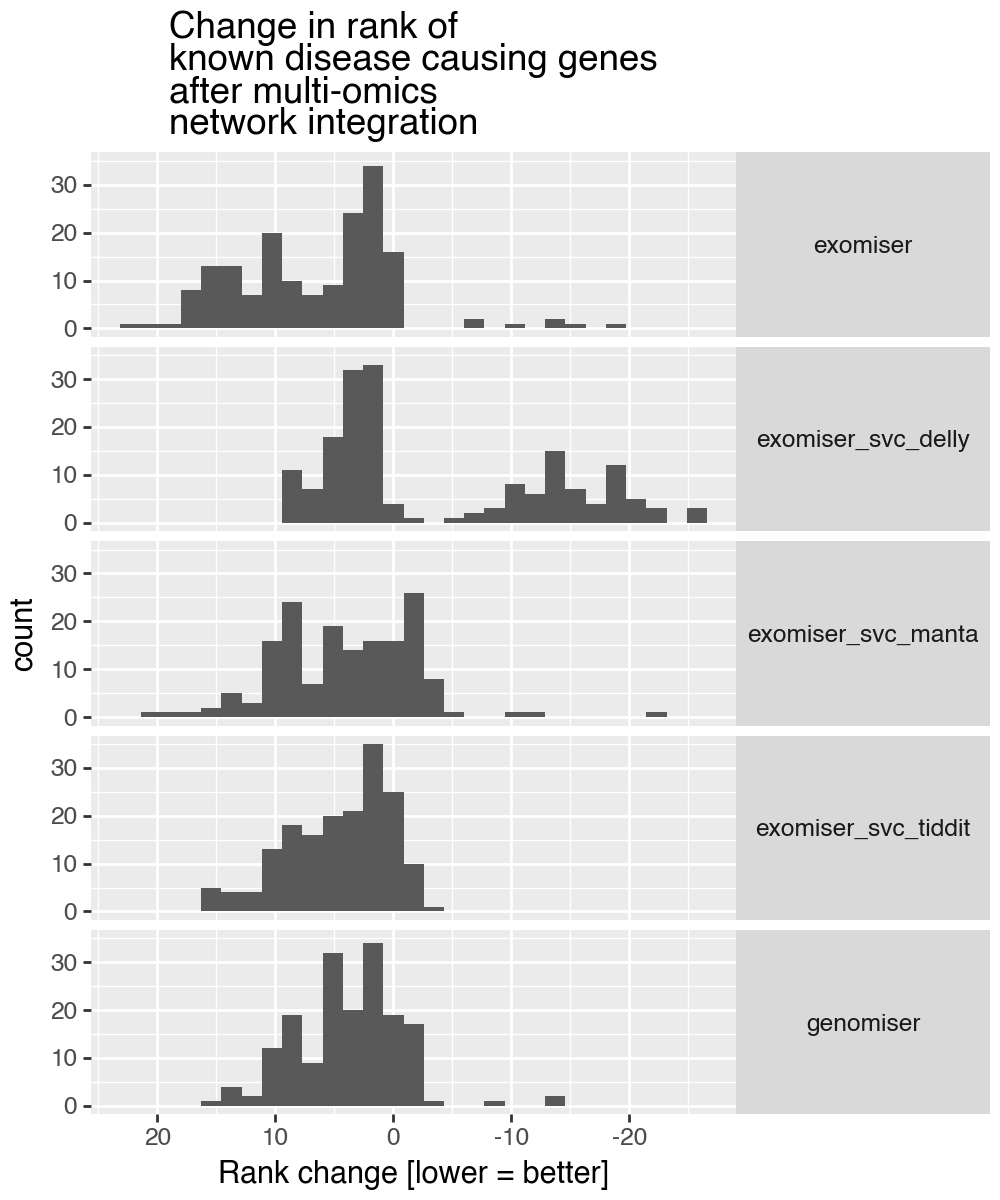

In [43]:
# get the change in rank for known

(dat_hits.query(f'{V.symbol} == {V.known_gene}')
     .eval(f'{V.delta_rank} = {V.re_rank}-{V.exomiser_rank}')
     >> pn.ggplot(pn.aes(x=V.delta_rank))
     + pn.facet_grid(f'{V.exomiser_pipeline}~.')
     +pn.geom_histogram()
     + pn.theme(figure_size=(5,6),
               strip_text_y=pn.element_text(angle=0))
     + pn.ggtitle('Change in rank of\n'
                  'known disease causing '
                  'genes\n'
                  'after multi-omics\nnetwork integration')
     + pn.coord_trans(x='reverse')
 + pn.xlab('Rank change [lower = better]')
)

In [44]:
dat_hits[V.sample_subgroup]

0                mut
3                mut
5        undiagnosed
7        undiagnosed
8         unaffected
            ...     
54824    undiagnosed
54826     unaffected
54830     unaffected
54831     unaffected
54832    undiagnosed
Name: subgroup, Length: 13329, dtype: category
Categories (3, object): ['mut', 'undiagnosed', 'unaffected']

In [45]:
dat_exom

,sample_id,pipeline,RANK,ID,GENE_SYMBOL,ENTREZ_GENE_ID,MOI,P-VALUE,EXOMISER_GENE_COMBINED_SCORE,EXOMISER_GENE_PHENO_SCORE,...,OMIM_SCORE,MATCHES_CANDIDATE_GENE,HUMAN_PHENO_EVIDENCE,MOUSE_PHENO_EVIDENCE,FISH_PHENO_EVIDENCE,HUMAN_PPI_EVIDENCE,MOUSE_PPI_EVIDENCE,FISH_PPI_EVIDENCE,subgroup,known_gene
0,MMA053,exomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9680,0.7250,...,1.0,0,"Methylmalonic aciduria, mut(0) type (OMIM:2510...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
1,MMA053,exomiser,2,NLGN4X_XR,NLGN4X,57502,XR,0.0136,0.1744,0.2913,...,1.0,0,"Autism susceptibility, X-linked 2 (OMIM:300495...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
2,MMA053,exomiser,2,NLGN4X_XD,NLGN4X,57502,XD,0.0136,0.1744,0.2913,...,1.0,0,"Autism susceptibility, X-linked 2 (OMIM:300495...",NaN,NaN,NaN,NaN,NaN,mut,MMUT
3,MMA053,exomiser,4,LMNA_AD,LMNA,4000,AD,0.0164,0.1439,0.2644,...,1.0,0,Mandibuloacral dysplasia with type A lipodystr...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
4,MMA053,exomiser,5,ZMYND15_AR,ZMYND15,84225,AR,0.0183,0.1285,0.2374,...,1.0,0,?Spermatogenic failure 14 (OMIM:615842): Methy...,NaN,NaN,NaN,NaN,NaN,mut,MMUT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56845,MMA163,genomiser,46,SLC6A19_AR,SLC6A19,340024,AR,0.0296,0.0735,0.6416,...,1.0,0,Hartnup disorder (OMIM:234500): Methylmalonic ...,NaN,NaN,NaN,NaN,NaN,undiagnosed,NaN
56846,MMA163,genomiser,47,NDUFS4_AR,NDUFS4,4724,AR,0.0299,0.0723,0.6227,...,1.0,0,"Mitochondrial complex I deficiency, nuclear ty...",NaN,NaN,NaN,NaN,NaN,undiagnosed,NaN
56847,MMA163,genomiser,48,HPD_AR,HPD,3242,AR,0.0305,0.0702,0.6577,...,1.0,0,Hawkinsinuria (OMIM:140350): Methylmalonic aci...,NaN,NaN,NaN,NaN,NaN,undiagnosed,NaN
56848,MMA163,genomiser,49,CD320_AR,CD320,51293,AR,0.0314,0.0670,0.8620,...,1.0,0,"Methylmalonic aciduria, transient, due to tran...",NaN,NaN,NaN,NaN,NaN,undiagnosed,NaN


In [46]:
(dat_exom.groupby([V.sample_subgroup, V.known_gene])[V.sample_id].nunique())

/var/folders/f1/mcz6x2cj135d8cvtysz3_bfc0000gn/T/ipykernel_51839/2302218283.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


subgroup     known_gene
mut          ACSF3           0
             MMAA            0
             MMAB            0
             MMUT          148
             SUCLA2          0
             TCN2            0
undiagnosed  ACSF3          20
             MMAA            2
             MMAB            1
             MMUT            0
             SUCLA2          3
             TCN2            3
unaffected   ACSF3           0
             MMAA            0
             MMAB            0
             MMUT            0
             SUCLA2          0
             TCN2            0
Name: sample_id, dtype: int64

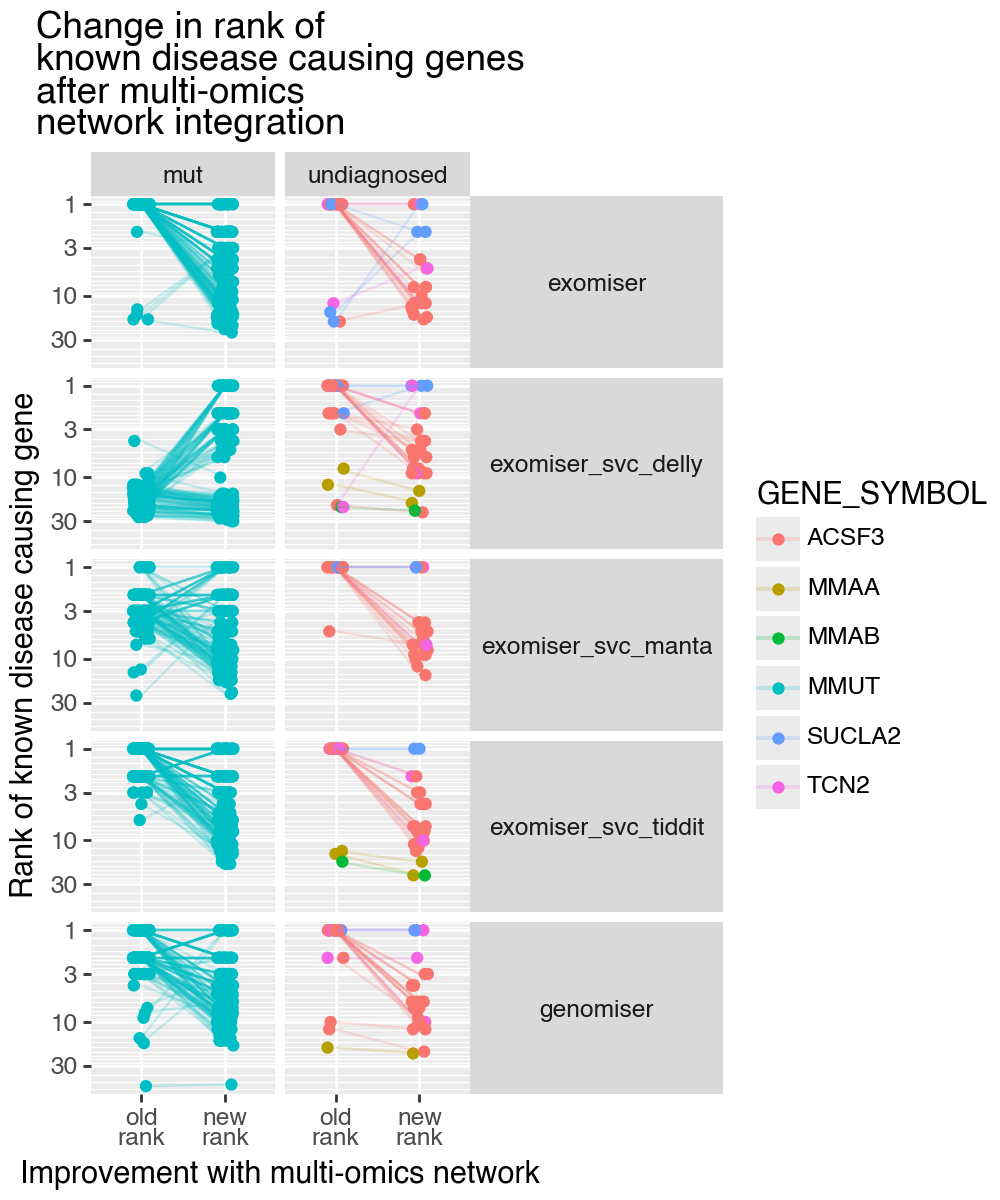

In [47]:
(dat_hits.query(f'{V.exomiser_gene_symbol} == {V.known_gene}')
    .rename(columns={V.exomiser_rank: 'old\nrank',
                    V.re_rank: 'new\nrank'    
                })
     .melt(id_vars=[V.sample_subgroup, 
                            V.sample_id, V.exomiser_gene_symbol,
                   V.exomiser_pipeline],
                  
                  value_vars=['old\nrank', 'new\nrank']).reset_index()
     
     >> pn.ggplot(pn.aes(x='variable', y='value' , color=V.exomiser_gene_symbol))
     + pn.facet_grid(f'{V.exomiser_pipeline}~{V.sample_subgroup}')
     +pn.geom_jitter(width=0.1, height=0)
     + pn.geom_line(pn.aes(group=f'{V.sample_id}+{V.exomiser_pipeline}'), alpha=0.2)
     + pn.theme(figure_size=(5,6),
               strip_text_y=pn.element_text(angle=0))
     + pn.scale_y_log10()
 + pn.coord_trans(y='reverse', x='reverse')
     + pn.ggtitle('Change in rank of\n'
                  'known disease causing '
                  'genes\n'
                  'after multi-omics\nnetwork integration')
 + pn.xlab('Improvement with multi-omics network')
 + pn.ylab('Rank of known disease causing gene')
)

In [48]:
dat_hits.groupby(V.known_gene)[V.sample_id].nunique()

known_gene
ACSF3      20
MMAA        2
MMAB        1
MMUT      148
SUCLA2      3
TCN2        3
Name: sample_id, dtype: int64

In [49]:
(dat_merged
    .eval(f'{V.is_retrieved} = `{V.attribute_rank_min}`.notna()')
    .query(f'{V.exomiser_gene_symbol} == {V.known_gene}')
    
    .groupby([V.is_retrieved, V.known_gene])[V.sample_id].nunique())

is_retrieved  known_gene
False         ACSF3         14
              MMAA           2
              MMAB           1
              MMUT          80
              TCN2           1
True          ACSF3          6
              MMUT          68
              SUCLA2         3
              TCN2           2
Name: sample_id, dtype: int64

In [50]:
(dat_merged
    .eval(f'{V.is_retrieved} = `{V.attribute_rank_min}`.notna()')
    .query(f'{V.exomiser_gene_symbol} == {V.known_gene}')
)

,sample_id,pipeline,RANK,ID,GENE_SYMBOL,ENTREZ_GENE_ID,MOI,P-VALUE,EXOMISER_GENE_COMBINED_SCORE,EXOMISER_GENE_PHENO_SCORE,...,attribute_rank.proteomics,attribute_rank.transcriptomics,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,combined_rank,re_rank,delta_rank,is_retrieved
0,MMA053,exomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9680,0.7250,...,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,14.0,13.0,False
3,MMA112,exomiser_svc_tiddit,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,NaN,403.0,NaN,1.465657,1.465657,403.0,202.0,2.0,1.0,True
5,MMA156,exomiser_svc_manta,1,ACSF3_AR,ACSF3,197322,AR,0.0000,0.9933,0.8891,...,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,5.0,4.0,False
9,MMA003,genomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9680,0.7250,...,NaN,NaN,NaN,NaN,NaN,NaN,3000.5,7.0,6.0,False
15,MMA023,genomiser,1,MMUT_AR,MMUT,4594,AR,0.0001,0.9668,0.7250,...,NaN,116.0,NaN,2.370883,2.370883,116.0,58.5,2.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31477,MMA016,exomiser_svc_delly,26,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,NaN,NaN,NaN,NaN,NaN,NaN,3013.0,28.0,2.0,False
31748,MMA141,exomiser_svc_delly,27,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,NaN,369.0,NaN,1.849951,1.849951,369.0,198.0,1.0,-26.0,True
31991,MMA011,exomiser_svc_delly,27,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,NaN,NaN,NaN,NaN,NaN,NaN,3013.5,30.0,3.0,False
32158,MMA100,exomiser_svc_delly,27,MMUT_AR,MMUT,4594,AR,0.0001,0.9687,0.7250,...,NaN,124.0,NaN,3.067378,3.067378,124.0,75.5,1.0,-26.0,True


In [51]:
(dat_hits.query(f'{V.exomiser_gene_symbol} == {V.known_gene}')
    .query(f'{V.exomiser_pipeline} == "genomiser"')
     .sort_values(V.delta_rank)
     [[
         V.sample_id, V.exomiser_rank, V.exomiser_id, V.exomiser_gene_symbol, V.re_rank, V.delta_rank,
         V.attribute_rank_min, 
         V.log2_enrichment_max
     ]]
 
)

,sample_id,RANK,ID,GENE_SYMBOL,re_rank,delta_rank,attribute_rank.min,log2_enrichment.max
19401,MMA047,17,MMUT_AR,MMUT,3.0,-14.0,500.0,0.924150
16736,MMA122,15,MMUT_AR,MMUT,1.0,-14.0,343.0,1.222972
9271,MMA060,9,MMUT_AR,MMUT,1.0,-8.0,734.0,0.675284
7155,MMA057,7,MMUT_AR,MMUT,3.0,-4.0,125.0,2.992738
54555,MMA077,50,MMUT_AR,MMUT,48.0,-2.0,NaN,NaN
...,...,...,...,...,...,...,...,...
2593,MMA056,3,MMUT_AR,MMUT,16.0,13.0,NaN,NaN
1259,MMA041,2,MMUT_AR,MMUT,15.0,13.0,NaN,NaN
2033,MMA030,2,MMUT_AR,MMUT,16.0,14.0,NaN,NaN
1903,MMA064,2,MMUT_AR,MMUT,16.0,14.0,NaN,NaN


## Undiagnosed patients — novel candidate discovery

For patients without a published causal gene we inspect the top re-ranked candidates
(combined `re_rank < 15`) to identify genes that rise due to corroborating multi-omics
network evidence. These are the most actionable outputs of the pipeline.

Selected patients are inspected individually below.

In [52]:
dat_new_hits = (dat_hits.query(f'{V.known_gene}.isna()')

 .query(f'{V.re_rank} < 15')
[[V.exomiser_pipeline, V.sample_id, V.symbol, V.log2_enrichment_prot,
  V.log2_enrichment_trans,
  V.log2_enrichment_max,
  V.attribute_rank_min, 	
  V.exomiser_rank,
  V.combined_rank,
  V.re_rank, V.exomiser_id, V.exomiser_p_value, V.exomiser_score
 ]].sort_values([V.sample_id, V.re_rank])

)
(dat_new_hits    .query(f'{V.exomiser_pipeline} == "genomiser"')
    
.pivot_table(index=[V.sample_id], values=V.exomiser_id, columns=V.re_rank, aggfunc=list)
)

re_rank,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
sample_id,,,,,,,,,,,,,,
MMA088,[HLCS_AR],[FTCD_AR],[GGT1_AR],[CASR_AD],[SLC22A5_AR],[HNF4A_AD],[STK11_AD],[SUGCT_AR],[ACSF3_AR],[DHTKD1_AR],"[HPD_AD, ASS1_AR]",NaN,[L2HGDH_AR],[ETFB_AR]
MMA139,[ASL_AR],[MMUT_AR],[GLUD1_AD],[TPK1_AR],[FTCD_AR],[CA5A_AR],[LMBRD1_AR],[HPD_AD],[MTR_AR],[HLCS_AR],[OCRL_XR],[CASR_AD],[CLCN5_XR],[SUGCT_AR]
MMA153,[CAD_AR],[SUCLG1_AR],[UROS_AR],[SLC25A1_AR],[HIBCH_AR],[MTR_AR],[HLCS_AR],[SUGCT_AR],[TCN2_AR],[ACSF3_AR],[HPD_AD],[CD320_AR],[ATP5F1A_AD],[DHTKD1_AR]
MMA157,[CPS1_AR],[SLC7A7_AR],[GCLC_AR],[FTCD_AR],[MLYCD_AR],[DHTKD1_AR],[SUGCT_AR],[TPK1_AR],[PEX14_AR],[CA5A_AR],[HPD_AR],[ACAD8_AR],[OPLAH_AD],[ACSF3_AR]
MMA159,[UQCRB_AR],[IBA57_AR],[ACSF3_AR],[HIBCH_AR],[HPD_AD],[OTC_XR],[ABCD4_AR],[SFXN4_AR],[SLC7A7_AR],[SUGCT_AR],[PEX14_AR],[ACADS_AR],[FAH_AR],[TCN2_AR]
MMA161,[SLC3A1_AD],[SLC25A1_AR],[SLC16A12_AD],[SLC6A19_AR],[HPD_AD],[FOCAD_AR],[MOCS2_AR],[HGD_AR],[TCN2_AR],[SUGCT_AR],[DHTKD1_AR],[PEX14_AR],[SLC13A3_AR],[ETFB_AR]
MMA162,[SLC3A1_AR],[LMBRD1_AR],[D2HGDH_AR],[SLC13A3_AR],[TPK1_AR],[HPD_AD],[DMGDH_AR],[MLYCD_AR],[CD320_AR],[NDUFAF6_AR],[HIBCH_AR],[ACSF3_AR],[ABCD4_AR],[PGM2L1_AR]
MMA163,[ETHE1_AR],[DLD_AR],[SUGCT_AR],[TBC1D24_AR],[DHTKD1_AR],[PEX14_AR],[MVK_AR],[MLYCD_AR],[SUCLA2_AR],[ACSF3_AR],[TNFRSF11A_AD],[SLC25A21_AR],[MOCS2_AR],[HADH_AR]
MMA166,[PCCA_AR],[HLCS_AR],[SLC25A21_AR],[MTR_AR],[TBC1D24_AR],[SLC7A9_AD],[MMACHC_AR],[FARS2_AR],[FTCD_AR],[SLC25A1_AR],[HPD_AD],[TCN2_AR],[ACSF3_AR],[ETFB_AR]


MMA 153 -> SUCLG1

In [53]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA088"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
24692,exomiser,MMA088,TAS2R43,NaN,0.340221,0.340221,1052.0,20,536.0,1.0,TAS2R43_AR,0.0581,0.0162
31314,exomiser_svc_tiddit,MMA088,RHD,0.261487,NaN,0.261487,1437.0,26,731.5,1.0,RHD_AR,0.0046,0.4375
32676,genomiser,MMA088,HLCS,0.120652,2.536088,2.536088,180.0,28,104.0,1.0,HLCS_AR,0.0046,0.4408
51311,exomiser_svc_manta,MMA088,FAN1,NaN,2.027676,2.027676,292.0,47,169.5,1.0,FAN1_AR,0.0048,0.4345
52911,exomiser_svc_delly,MMA088,SCO1,2.571562,NaN,2.571562,133.0,48,90.5,1.0,SCO1_AR,0.0004,0.9221
195,exomiser_svc_delly,MMA088,SUCLA2,NaN,NaN,NaN,NaN,1,3000.5,2.0,SUCLA2_AR,0.0000,0.9922
6772,exomiser_svc_manta,MMA088,CASR,0.286197,0.302916,0.302916,1168.0,7,587.5,2.0,CASR_AD,0.0006,0.8843
24640,exomiser,MMA088,DKK4,0.175158,0.232363,0.232363,1472.0,20,746.0,2.0,DKK4_AD,0.0583,0.0162
40987,exomiser_svc_tiddit,MMA088,NPHS1,0.130356,0.151034,0.151034,2232.0,36,1134.0,2.0,NPHS1_AD,0.0074,0.3043
44563,genomiser,MMA088,FTCD,0.309434,NaN,0.309434,1101.0,40,570.5,2.0,FTCD_AR,0.0058,0.3700


In [54]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA139"')
     .query(f'{V.symbol} == "MMUT"')
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
18177,exomiser_svc_delly,MMA139,MMUT,NaN,1.772872,1.772872,303.0,16,159.5,1.0,MMUT_AR,0.0001,0.9687
3743,genomiser,MMA139,MMUT,NaN,1.772872,1.772872,303.0,4,153.5,2.0,MMUT_AR,0.0007,0.8864


In [55]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA153"')
    .head(10)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
9664,exomiser_svc_tiddit,MMA153,CAD,2.058626,NaN,2.058626,137.0,9,73.0,1.0,CAD_AR,0.0027,0.5832
10565,genomiser,MMA153,CAD,2.058626,NaN,2.058626,137.0,10,73.5,1.0,CAD_AR,0.0018,0.7062
16546,exomiser_svc_manta,MMA153,SNX14,NaN,2.888592,2.888592,73.0,15,44.0,1.0,SNX14_AR,0.0018,0.7163
43362,exomiser,MMA153,CAD,2.058626,NaN,2.058626,137.0,39,88.0,1.0,CAD_AD,0.0681,0.0147
51729,exomiser_svc_delly,MMA153,GALE,2.634976,NaN,2.634976,35.0,47,41.0,1.0,GALE_AR,0.0006,0.8911
367,exomiser,MMA153,SUCLG1,1.767032,NaN,1.767032,198.0,1,99.5,2.0,SUCLG1_AR,0.0005,0.9118
1520,exomiser_svc_tiddit,MMA153,SUCLG1,1.767032,NaN,1.767032,198.0,2,100.0,2.0,SUCLG1_AR,0.0005,0.9118
4037,genomiser,MMA153,SUCLG1,1.767032,NaN,1.767032,198.0,4,101.0,2.0,SUCLG1_AR,0.0004,0.9118
40924,exomiser_svc_manta,MMA153,APPL1,2.368339,NaN,2.368339,74.0,36,55.0,2.0,APPL1_AD,0.0037,0.5079
50322,exomiser_svc_delly,MMA153,CAD,2.058626,NaN,2.058626,137.0,46,91.5,2.0,CAD_AR,0.0005,0.9022


In [56]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA157"')
    
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
17237,exomiser,MMA157,ANKRD27,NaN,3.574420,3.574420,42.0,15,28.5,1.0,ANKRD27_AD,0.0580,0.0162
24386,genomiser,MMA157,CPS1,2.796504,NaN,2.796504,99.0,20,59.5,1.0,CPS1_AR,0.0052,0.3979
25707,exomiser_svc_manta,MMA157,GYS2,2.496227,0.170730,2.496227,118.0,21,69.5,1.0,GYS2_AR,0.0024,0.6290
32730,exomiser_svc_tiddit,MMA157,PRDX1,3.393859,NaN,3.393859,52.0,28,40.0,1.0,PRDX1_AR,0.0056,0.3878
35439,exomiser_svc_delly,MMA157,PRDX1,3.393859,NaN,3.393859,52.0,30,41.0,1.0,PRDX1_AR,0.0002,0.9666
17368,exomiser,MMA157,ANXA2,2.801252,NaN,2.801252,97.0,15,56.0,2.0,ANXA2_AD,0.0576,0.0162
31101,exomiser_svc_delly,MMA157,MMUT,1.949697,NaN,1.949697,190.0,26,108.0,2.0,MMUT_AR,0.0001,0.9687
45138,genomiser,MMA157,SLC7A7,0.181371,NaN,0.181371,2058.0,41,1049.5,2.0,SLC7A7_AR,0.0108,0.2149
48569,exomiser_svc_manta,MMA157,BLVRA,2.438946,NaN,2.438946,128.0,44,86.0,2.0,BLVRA_AD,0.0045,0.4435
52499,exomiser_svc_tiddit,MMA157,PMP22,0.412968,NaN,0.412968,817.0,48,432.5,2.0,PMP22_AD,0.0090,0.2590


In [57]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA159"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
27505,exomiser_svc_delly,MMA159,MMAB,3.106560,NaN,3.106560,81.0,23,52.0,1.0,MMAB_AR,0.0001,0.9728
29839,exomiser_svc_tiddit,MMA159,MMAB,3.106560,NaN,3.106560,81.0,25,53.0,1.0,MMAB_AR,0.0040,0.4759
43810,exomiser_svc_manta,MMA159,PKD2,2.552643,NaN,2.552643,124.0,39,81.5,1.0,PKD2_AD,0.0039,0.4862
44144,exomiser,MMA159,ELP2,NaN,4.835142,4.835142,14.0,40,27.0,1.0,ELP2_AD,0.0599,0.0160
47036,genomiser,MMA159,UQCRB,1.264476,NaN,1.264476,285.0,43,164.0,1.0,UQCRB_AR,0.0143,0.1681
2427,exomiser,MMA159,ATXN3,2.003279,NaN,2.003279,180.0,3,91.5,2.0,ATXN3_AD,0.0123,0.1968
35029,genomiser,MMA159,IBA57,NaN,0.164507,0.164507,1566.0,30,798.0,2.0,IBA57_AR,0.0093,0.2604
37342,exomiser_svc_delly,MMA159,PIGB,0.192454,3.600418,3.600418,75.0,32,53.5,2.0,PIGB_AR,0.0001,0.9633
40998,exomiser_svc_tiddit,MMA159,PIGB,0.192454,3.600418,3.600418,75.0,36,55.5,2.0,PIGB_AR,0.0052,0.3999
45313,exomiser_svc_manta,MMA159,TMEM270,0.677728,NaN,0.677728,501.0,41,271.0,2.0,TMEM270_AD,0.0042,0.4633


In [58]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA161"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
11806,exomiser_svc_delly,MMA161,IDH2,NaN,2.200801,2.200801,227.0,11,119.0,1.0,IDH2_AD,0.0001,0.9770
35578,exomiser_svc_tiddit,MMA161,SLC16A12,0.672548,0.560794,0.672548,540.0,31,285.5,1.0,SLC16A12_AD,0.0072,0.3151
38083,exomiser,MMA161,C1orf50,NaN,3.785086,3.785086,67.0,33,50.0,1.0,C1orf50_AD,0.0587,0.0161
51304,genomiser,MMA161,SLC3A1,NaN,5.312781,5.312781,1.0,47,24.0,1.0,SLC3A1_AD,0.0163,0.1450
51427,exomiser_svc_manta,MMA161,NHERF1,3.945857,NaN,3.945857,25.0,47,36.0,1.0,NHERF1_AD,0.0034,0.5229
151,exomiser_svc_delly,MMA161,SUCLA2,NaN,2.120745,2.120745,245.0,1,123.0,2.0,SUCLA2_AR,0.0000,0.9922
16188,exomiser_svc_tiddit,MMA161,MMAA,0.203345,NaN,0.203345,1403.0,14,708.5,2.0,MMAA_AR,0.0034,0.5295
17555,exomiser,MMA161,ENO1,2.674981,2.315727,2.674981,102.0,15,58.5,2.0,ENO1_AD,0.0579,0.0162
23608,exomiser_svc_manta,MMA161,TREX1,NaN,3.151368,3.151368,126.0,20,73.0,2.0,TREX1_AD,0.0020,0.6887
25184,genomiser,MMA161,SLC25A1,NaN,1.646755,1.646755,351.0,21,186.0,2.0,SLC25A1_AR,0.0055,0.3979


In [59]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA162"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
4577,exomiser_svc_delly,MMA162,LMBRD1,0.335456,4.022490,4.022490,51.0,5,28.0,1.0,LMBRD1_AR,0.0001,0.9784
17870,exomiser,MMA162,NKAIN4,1.131603,NaN,1.131603,397.0,16,206.5,1.0,NKAIN4_AD,0.0585,0.0162
23932,exomiser_svc_manta,MMA162,ATPAF2,NaN,3.859846,3.859846,64.0,20,42.0,1.0,ATPAF2_AR,0.0008,0.8539
37246,exomiser_svc_tiddit,MMA162,TPK1,0.353839,0.642884,0.642884,676.0,32,354.0,1.0,TPK1_AR,0.0080,0.2864
51985,genomiser,MMA162,SLC3A1,0.611061,5.263855,5.263855,13.0,48,30.5,1.0,SLC3A1_AR,0.0162,0.1450
9796,exomiser_svc_manta,MMA162,HTRA2,2.788004,NaN,2.788004,123.0,9,66.0,2.0,HTRA2_AR,0.0003,0.9443
16255,exomiser_svc_delly,MMA162,HTRA2,2.788004,NaN,2.788004,123.0,14,68.5,2.0,HTRA2_AR,0.0003,0.9443
17960,exomiser,MMA162,ASAH2B,0.541849,NaN,0.541849,936.0,16,476.0,2.0,ASAH2B_AR,0.0583,0.0162
31588,exomiser_svc_tiddit,MMA162,COX16,0.551003,NaN,0.551003,916.0,26,471.0,2.0,COX16_AR,0.0068,0.3277
42905,genomiser,MMA162,LMBRD1,0.335456,4.022490,4.022490,51.0,38,44.5,2.0,LMBRD1_AR,0.0120,0.1977


In [60]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA163"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
4563,exomiser_svc_tiddit,MMA163,ABCC6,2.568896,NaN,2.568896,51.0,5,28.0,1.0,ABCC6_AR,0.0046,0.4472
16695,exomiser_svc_manta,MMA163,SPTLC1,2.274764,NaN,2.274764,87.0,15,51.0,1.0,SPTLC1_AD,0.0580,0.0162
36418,exomiser,MMA163,CAPN1,2.709209,2.035348,2.709209,37.0,31,34.0,1.0,CAPN1_AD,0.0736,0.0141
45154,genomiser,MMA163,ETHE1,NaN,2.139479,2.139479,228.0,41,134.5,1.0,ETHE1_AR,0.0239,0.0991
52997,exomiser_svc_delly,MMA163,UROD,2.562178,NaN,2.562178,53.0,49,51.0,1.0,UROD_AR,0.0014,0.7621
10605,exomiser_svc_delly,MMA163,PRDX1,1.826874,NaN,1.826874,188.0,10,99.0,2.0,PRDX1_AR,0.0001,0.9666
12948,exomiser,MMA163,GOLGA6L9,NaN,0.405346,0.405346,744.0,12,378.0,2.0,GOLGA6L9_AD,0.0578,0.0162
15441,genomiser,MMA163,DLD,NaN,0.502135,0.502135,681.0,14,347.5,2.0,DLD_AR,0.0047,0.4490
17123,exomiser_svc_manta,MMA163,GOLGA6L9,NaN,0.405346,0.405346,744.0,15,379.5,2.0,GOLGA6L9_AD,0.0580,0.0162
41084,exomiser_svc_tiddit,MMA163,GHR,0.183919,NaN,0.183919,1212.0,36,624.0,2.0,GHR_AD,0.0401,0.0411


In [61]:
(dat_new_hits
    .query(f'{V.sample_id} == "MMA169"')
    .head(20)
)

,pipeline,sample_id,symbol,log2_enrichment.proteomics,log2_enrichment.transcriptomics,log2_enrichment.max,attribute_rank.min,RANK,combined_rank,re_rank,ID,P-VALUE,EXOMISER_GENE_COMBINED_SCORE
5478,exomiser_svc_tiddit,MMA169,SUMF1,NaN,3.173909,3.173909,178.0,5,91.5,1.0,SUMF1_AR,0.0022,0.6664
5662,exomiser,MMA169,TBCD,NaN,3.211313,3.211313,168.0,6,87.0,1.0,TBCD_AR,0.0124,0.1896
17978,genomiser,MMA169,TCN2,0.441884,3.030679,3.030679,208.0,16,112.0,1.0,TCN2_AR,0.0038,0.4860
33909,exomiser_svc_manta,MMA169,GYS2,3.512889,0.135441,3.512889,62.0,29,45.5,1.0,GYS2_AR,0.0025,0.6290
47453,exomiser_svc_delly,MMA169,NEU1,3.288494,5.062753,5.062753,12.0,43,27.5,1.0,NEU1_AR,0.0004,0.9103
6955,exomiser_svc_tiddit,MMA169,BSND,NaN,0.467600,0.467600,1159.0,7,583.0,2.0,BSND_AR,0.0033,0.5430
7180,exomiser_svc_delly,MMA169,LMBRD1,1.072260,NaN,1.072260,526.0,7,266.5,2.0,LMBRD1_AR,0.0000,0.9784
24395,exomiser,MMA169,METTL23,NaN,2.856481,2.856481,241.0,20,130.5,2.0,METTL23_AD,0.0583,0.0162
39327,exomiser_svc_manta,MMA169,SDHC,1.615853,NaN,1.615853,404.0,35,219.5,2.0,SDHC_AD,0.0027,0.6039
53867,genomiser,MMA169,SLC3A1,NaN,1.823044,1.823044,435.0,49,242.0,2.0,SLC3A1_AR,0.0161,0.1450
